# Lecture pour entrainement pandas


In [1]:

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from networkx.relabel import relabel_nodes
from importlib import reload

from sklearn.compose import make_column_transformer

from core_periphery import *

In [29]:
network = create_core_periphery_network(50, 70, 0.000001, 0.00000001)

In [30]:
network.get_matrix_obligation()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(120, 120))

In [31]:
relative = network.get_matrix_relative_liabilities()
relative

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(120, 120))

In [32]:
b = network.get_vector_outside_liabilities()
b

array([2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500.,
       2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500.,
       2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500.,
       2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500.,
       2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500., 2500.,
       2500., 2500., 2500., 2500., 2500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,  500.,
        500.,  500.,  500.])

In [33]:
c = network.get_vector_outside_assets()
c

array([5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000.,
       5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000.,
       5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000.,
       5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000.,
       5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000., 5000.,
       5000., 5000., 5000., 5000., 5000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
       1000., 1000., 1000.])

In [27]:
# temporary code for the first visualisation part

import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from model import RandomNetwork, ManualNetwork, TrivialNetwork
from controller import Simulation
from core_periphery import create_core_periphery_network
from scale_free import create_scalefree_network
from scale_free import create_smallworld_network

# Fixer le générateur aléatoire
np.random.seed(42)

# Reseau core-periphery bizarre
number_bank = 1000
n_core = int(number_bank /2)
n_periphery = number_bank - n_core



#network_manual = TrivialNetwork(5000)




core_periphery_network = create_core_periphery_network(n_core, n_periphery, p_core=0.85, p_periphery=0.3)

#network_random = RandomNetwork(100, 0.00001)





# On fixe la taille du graphe, et on fait varier uniformément, le vector de shock, puis on plot la mesure du shock par rapport a la proportion de default.

default_count_vector = []
shock_measure_vector = []


#vector_outside_asset = np.copy(network_manual.get_vector_outside_assets())
vector_outside_asset = np.copy(core_periphery_network.get_vector_outside_assets())
#vector_outside_asset = np.copy(network_random.get_vector_outside_assets())
shock_vector = np.copy(vector_outside_asset/1000)
for k in range(0,1000):
    shock_vector = k*vector_outside_asset/1000
    #simulation_core_network = Simulation("Eisenberg", network_manual, shock_vector)
    simulation_core_network = Simulation("Eisenberg", core_periphery_network, shock_vector)
    #simulation_core_network = Simulation("Eisenberg",network_random, shock_vector)



    _ , shock_measure, default_count, _ = simulation_core_network.simulate()
    #network_manual.set_vector_outside_assets(vector_outside_asset)
    core_periphery_network.set_vector_outside_assets(vector_outside_asset)
    #network_random.set_vector_outside_assets(vector_outside_asset)




    shock_measure_vector.append(shock_measure)
    default_count_vector.append(default_count)


print("shock measure vector: ",shock_measure_vector)
print("default count vector ",default_count_vector)

plt.scatter( shock_measure_vector, default_count_vector)
plt.show()





In [46]:
a = np.zeros((5,5))
n = 4
for k in range(0,5):
    for l in range(0,5):
        if k >= l:
            a[k,l] = 0
            continue
        elif n == 0:
            a[k,l] = 0
            continue
        a[k,l] = 1/n
    n -= 1
a

array([[0.        , 0.25      , 0.25      , 0.25      , 0.25      ],
       [0.        , 0.        , 0.33333333, 0.33333333, 0.33333333],
       [0.        , 0.        , 0.        , 0.5       , 0.5       ],
       [0.        , 0.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [50]:
n = 4  # Valeur initiale de n (pour la première ligne)
size = 5
values = np.array([1/(n-i) if n-i > 0 else 0 for i in range(size)])

In [51]:
values

array([0.25      , 0.33333333, 0.5       , 1.        , 0.        ])

In [52]:
mask = np.triu(np.ones((size, size)), k=1).astype(bool)


In [53]:
mask

array([[False,  True,  True,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False, False,  True],
       [False, False, False, False, False]])

In [54]:
for i in range(size):
    # Créer un masque pour la ligne i (seulement partie triangulaire supérieure)
    row_mask = mask[i]
    # Appliquer la valeur correspondante
    a[i, row_mask] = values[i]

array([[0.        , 0.25      , 0.25      , 0.25      , 0.25      ],
       [0.        , 0.        , 0.33333333, 0.33333333, 0.33333333],
       [0.        , 0.        , 0.        , 0.5       , 0.5       ],
       [0.        , 0.        , 0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [58]:

size = 5
n_initial = 4

# Créer une matrice de zéros
a = np.zeros((size, size))

# Créer le masque pour partie triangulaire supérieure stricte
mask = np.triu(np.ones((size, size)), k=1).astype(bool)

# Créer un vecteur de valeurs 1/n pour chaque ligne, où n > 0
n_values = n_initial - np.arange(size)
values = np.zeros(size)
values[n_values > 0] = 1 / n_values[n_values > 0]

# Utiliser broadcasting pour créer la matrice finale
a[mask] = np.repeat(values, np.sum(mask, axis=1))

In [61]:
a @ np.array([1]*5)

array([1., 1., 1., 1., 0.])

In [9]:
import numpy as np

np.sum(np.array([[-1, 1, 1, 1, 1], [-1, 1, 1, 1, 1], [-1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1] ]), axis=0)


array([-1,  5,  5,  5,  5])

shock measure vector:  0.24813895781637718
default count vector  0.25


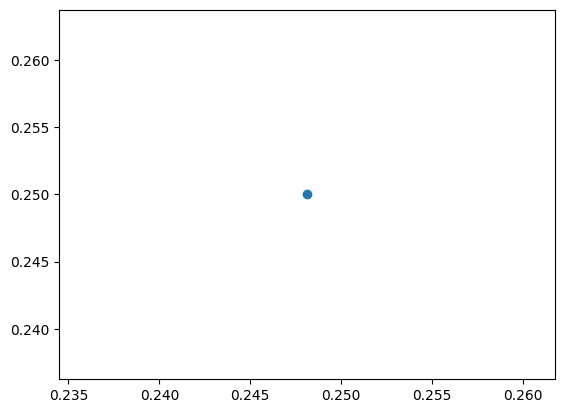